<h1 style="font-size: 1.6rem; font-weight: bold">ITO 5221: Intelligent Image and Video Analysis</h1>
<h1 style="font-size: 1.6rem; font-weight: bold">Module 3.1: Deep Learning for Computer Vision</h1>
<p style="margin-top: 5px; margin-bottom: 5px;">Monash University Australia</p>
<p style="margin-top: 5px; margin-bottom: 5px;">Jupyter Notebook by: Tristan Sim Yook Min</p>
References: Information Source from Monash Faculty of Information Technology

---


### **Representation Learning**

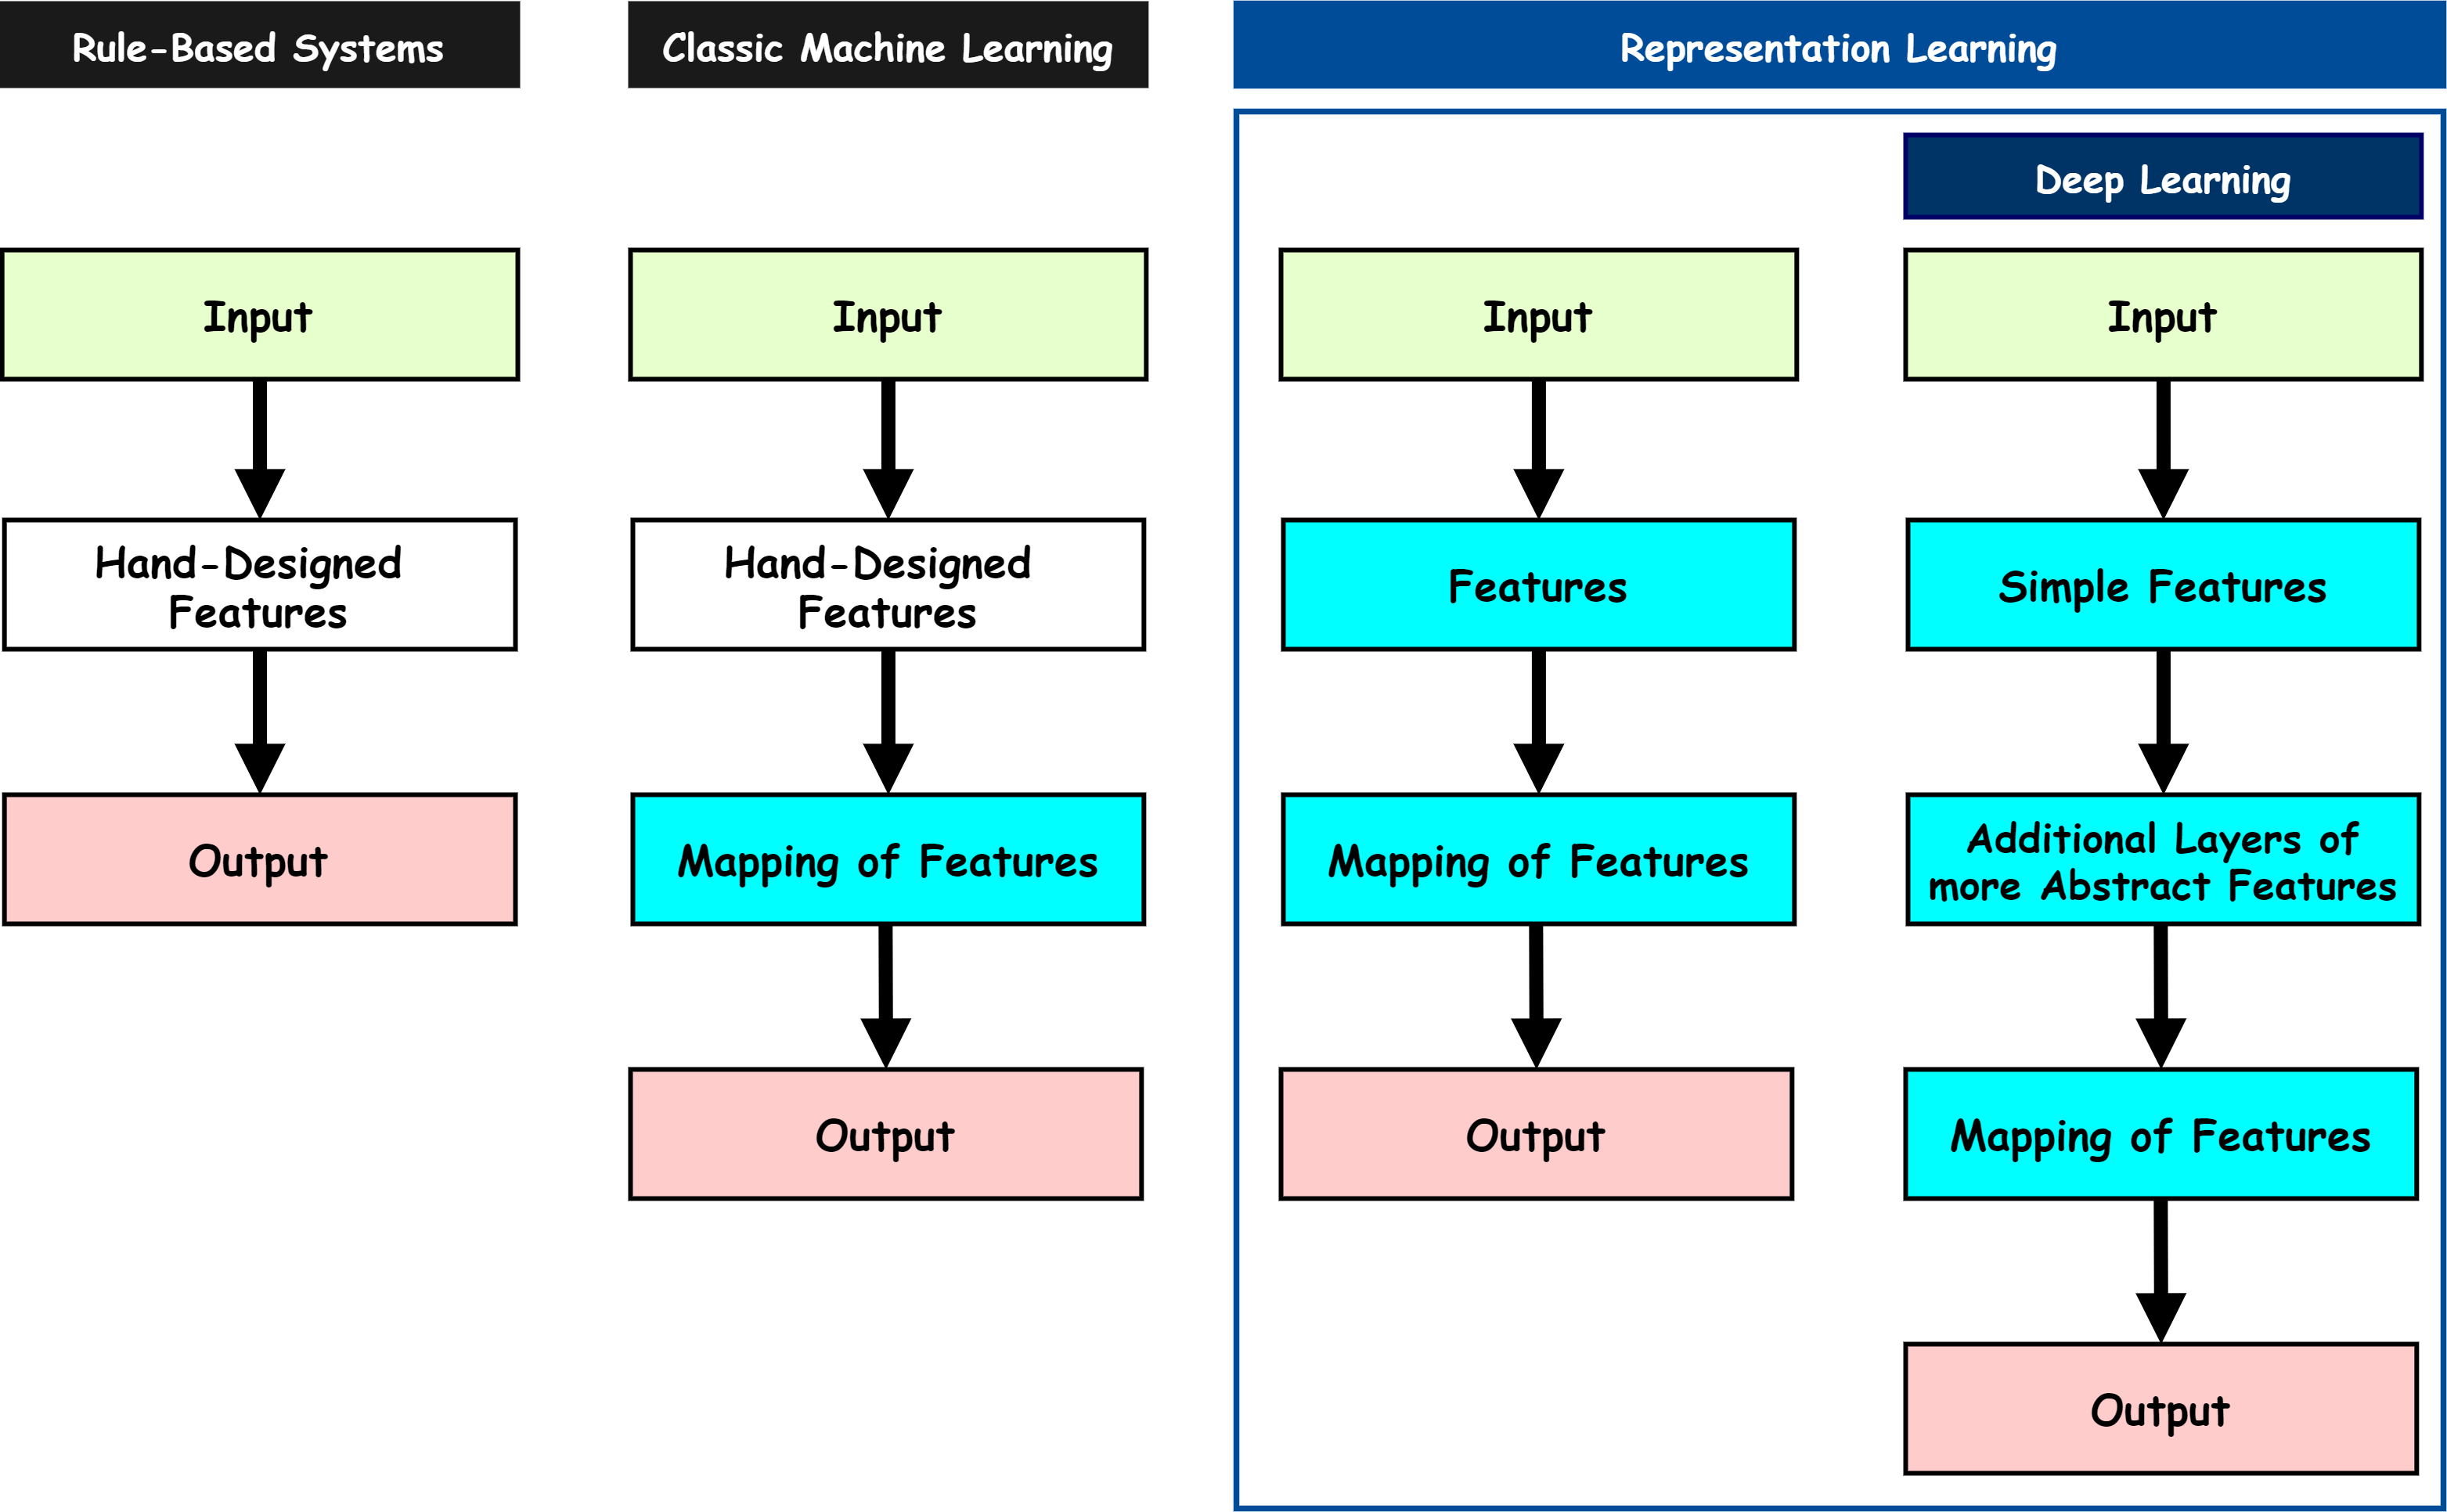

Understanding how image analysis has evolved helps frame why representation learning matters. Consider **skin detection** as a running example:

**Rule-based systems**: In the early days, skin pixels were identified using hand-designed programs based on simple rules like RGB value thresholds. No learning was involved.

**Classic machine learning**: Are hand-designed features (e.g., RGB values) are fed into a trained model like an SVM, which learns the mapping from features to labels. The features are still manually chosen.

**Representation learning**: Instead of hand-designed features like SIFT or LBP, a neural network learns its own feature representations in the hidden layers. The network simultaneously extracts useful features and uses them to predict the output.

**Deep learning**: The number of layers increases significantly, allowing the network to learn increasingly abstract and complex features. Deeper models are generally more powerful for challenging tasks.

For example, skin detection can be approached by feeding HSV/RGB histograms into a multi-layer perceptron, or alternatively by feeding the **raw image pixels** directly into a deep network and letting it learn everything end-to-end.

#### **ImageNet Challenge**

The ImageNet dataset has been a key benchmark for tracking progress in image classification. In 2010–2011, non-deep-learning models achieved error rates of 28.2% and 25.8%. After **AlexNet** was introduced in 2012, the error rate dropped dramatically, marking the point where deep learning took over. A clear trend is that networks kept getting deeper: by 2015, **ResNet** reached 152 layers with a corresponding drop in error rate.

A similar pattern appears in **object detection**. The mean Average Precision (mAP) metric remained relatively flat from 2010 to 2012, but improved sharply after 2013 when deep learning methods became dominant.

Today, deep learning is widely adopted across both research and industry for solving computer vision problems.

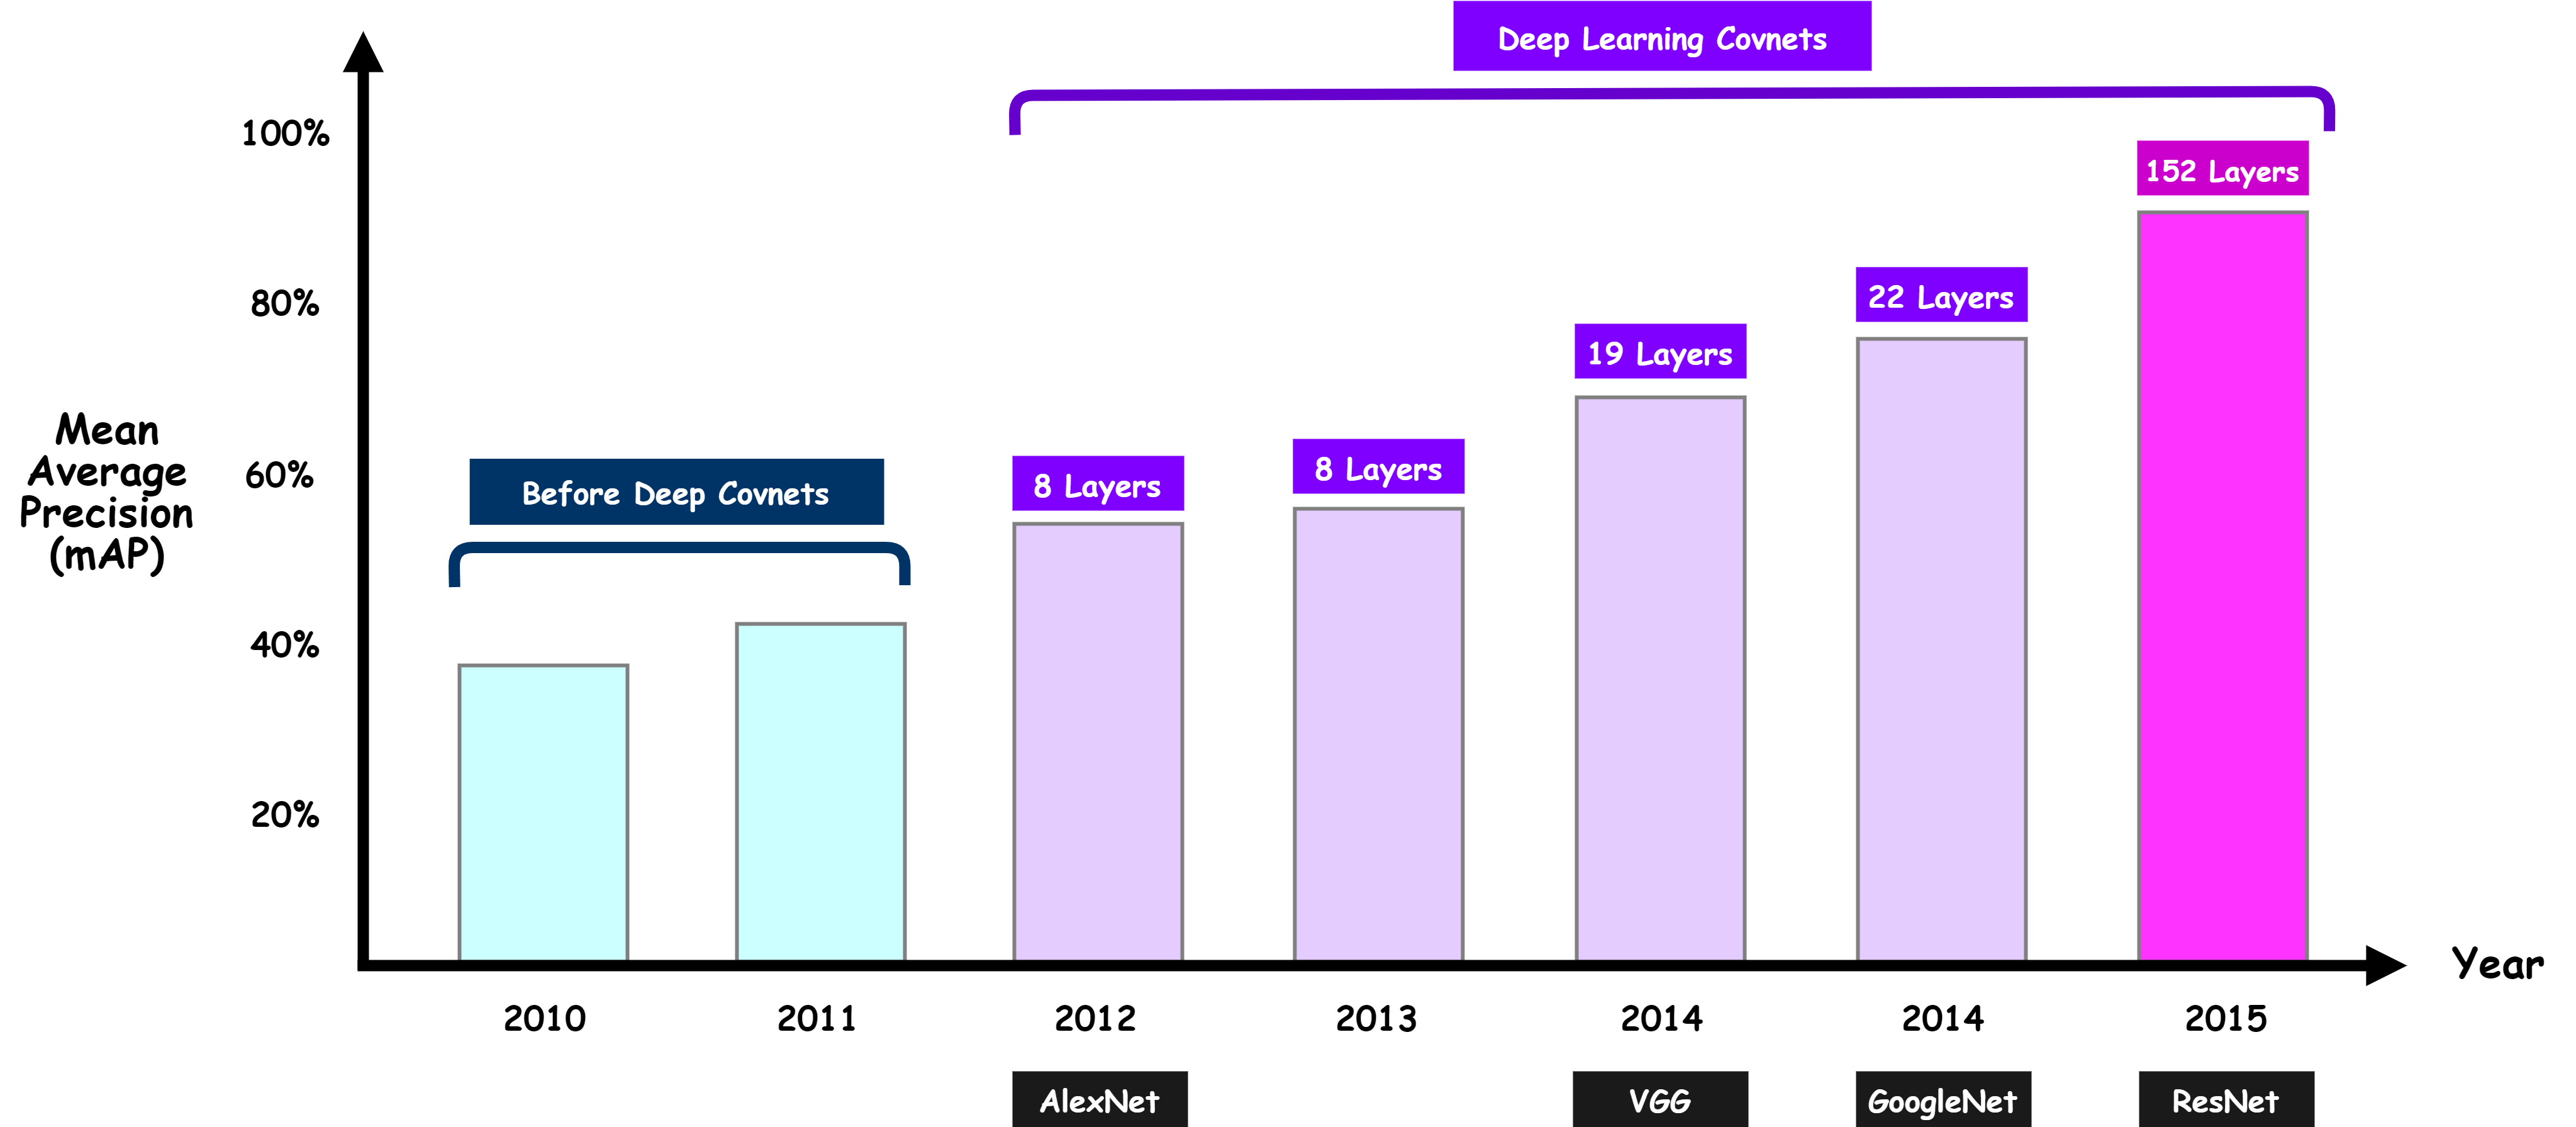

***

### **Multi-Layer Networks and Training**

#### **The Perceptron**

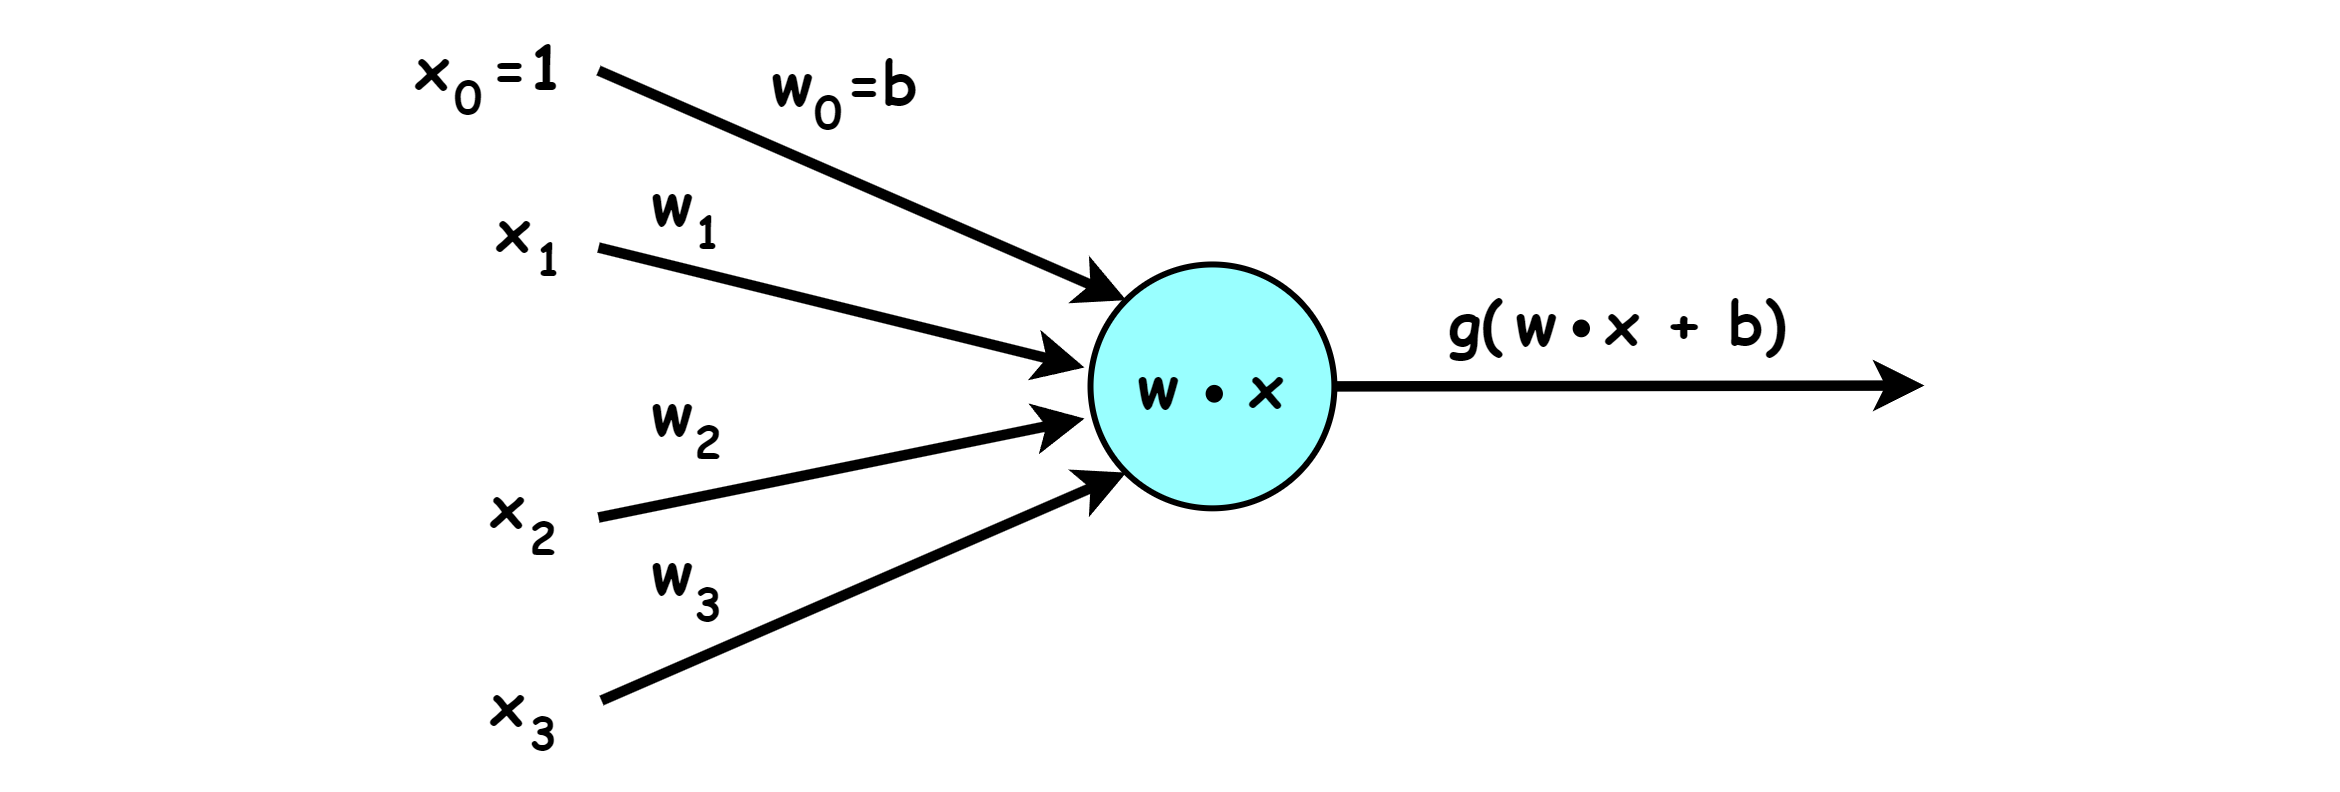

Modern neural networks are built on the **perceptron** — the simplest possible neural unit. It takes an input vector $x_1$ to $x_D$, multiplies each by a learned weight $w_1$ to $w_D$, adds a bias $b$, and produces a binary output:

$$f(x)= \begin{cases}1 & \text{if } \mathbf{w} \cdot \mathbf{x}+b>0 \\ 0 & \text{else}\end{cases}$$

The weights and bias are learned from training data. After training, the perceptron can classify inputs as positive or negative based on which side of the decision boundary they fall.

#### **From Perceptron to Neural Networks**

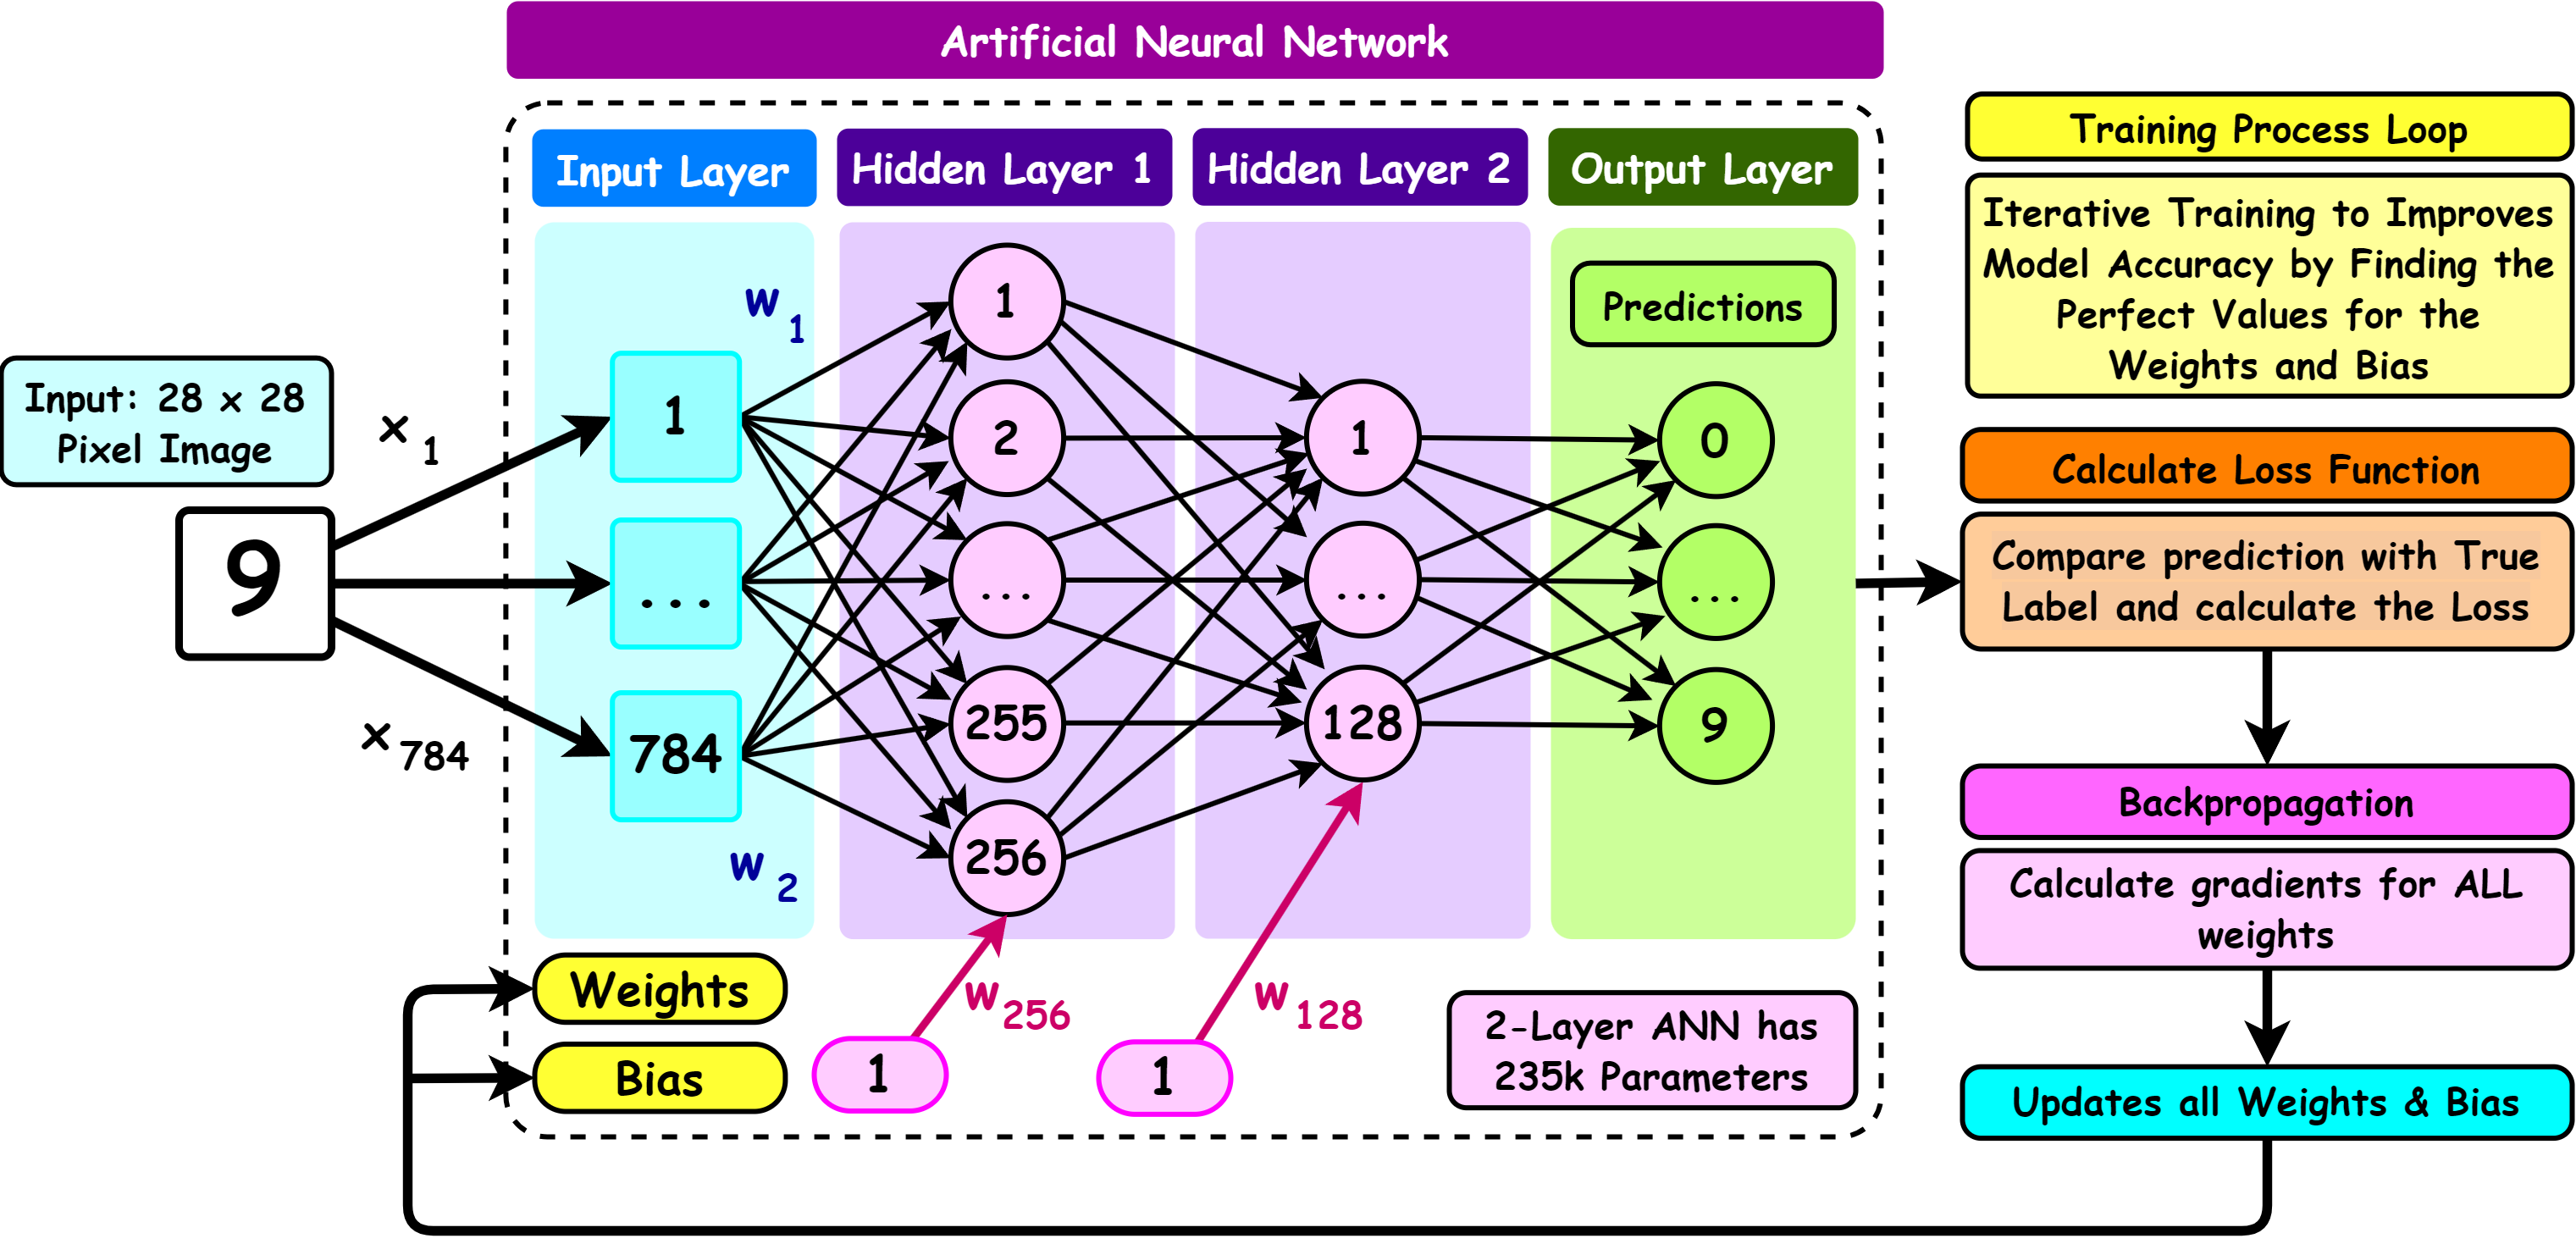

By stacking multiple perceptrons into layers, we form a **neural network**. However, the simple step function used by the perceptron is replaced with smoother **activation functions** like:

- **Sigmoid**: squashes values to the range $(0, 1)$
- **ReLU**: outputs $\max(0, x)$, which is simple and effective for deep networks

These smooth activations are essential because they allow gradients to flow through the network during training.

#### **Neural Network Playground**

[Open TensorFlow Playground](http://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=5,2&seed=0.42952&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false)

#### **Training with Backpropagation**

The goal of training is to find network weights that **minimise the error** between the true labels and the model's predictions. The error (or loss) is measured as:

$$E(\mathbf{w})=\sum_{i=1}^{N}\left(y_{i}-f_{\mathbf{w}}\left(\mathbf{x}_{i}\right)\right)^{2}$$

Weights are updated iteratively using **gradient descent** adjusting each weight in the direction that reduces the error:

$$\mathbf{w} \leftarrow \mathbf{w}-\alpha \frac{\partial E}{\partial \mathbf{w}}$$

Where $\alpha$ is the **learning rate**, which controls how large each update step is. This process repeats over many iterations until the error converges to a minimum.

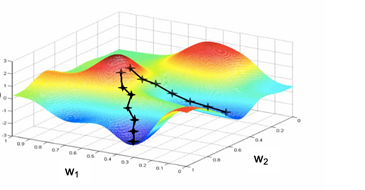

*Imnage Above Reference: Training of multi-layer networks (2022) courtesy of the Monash Faculty of Information Technology*

**Backpropagation:** Gradients are computed in the direction from the **output layer back to the input layer**, combining partial derivatives at each layer using the **chain rule**. This efficiently tells each weight how much it contributed to the overall error.

**Stochastic Gradient Descent (SGD)**: Instead of computing the gradient over the entire dataset at once, SGD updates the weights based on **one training example** (or a small batch) at a time. The training examples are cycled through in **random order** across multiple **epochs** (full passes through the dataset). This is faster and often leads to better generalisation than using the full dataset for each update.

***

### **Convolutional Neural Networks (CNNs)**

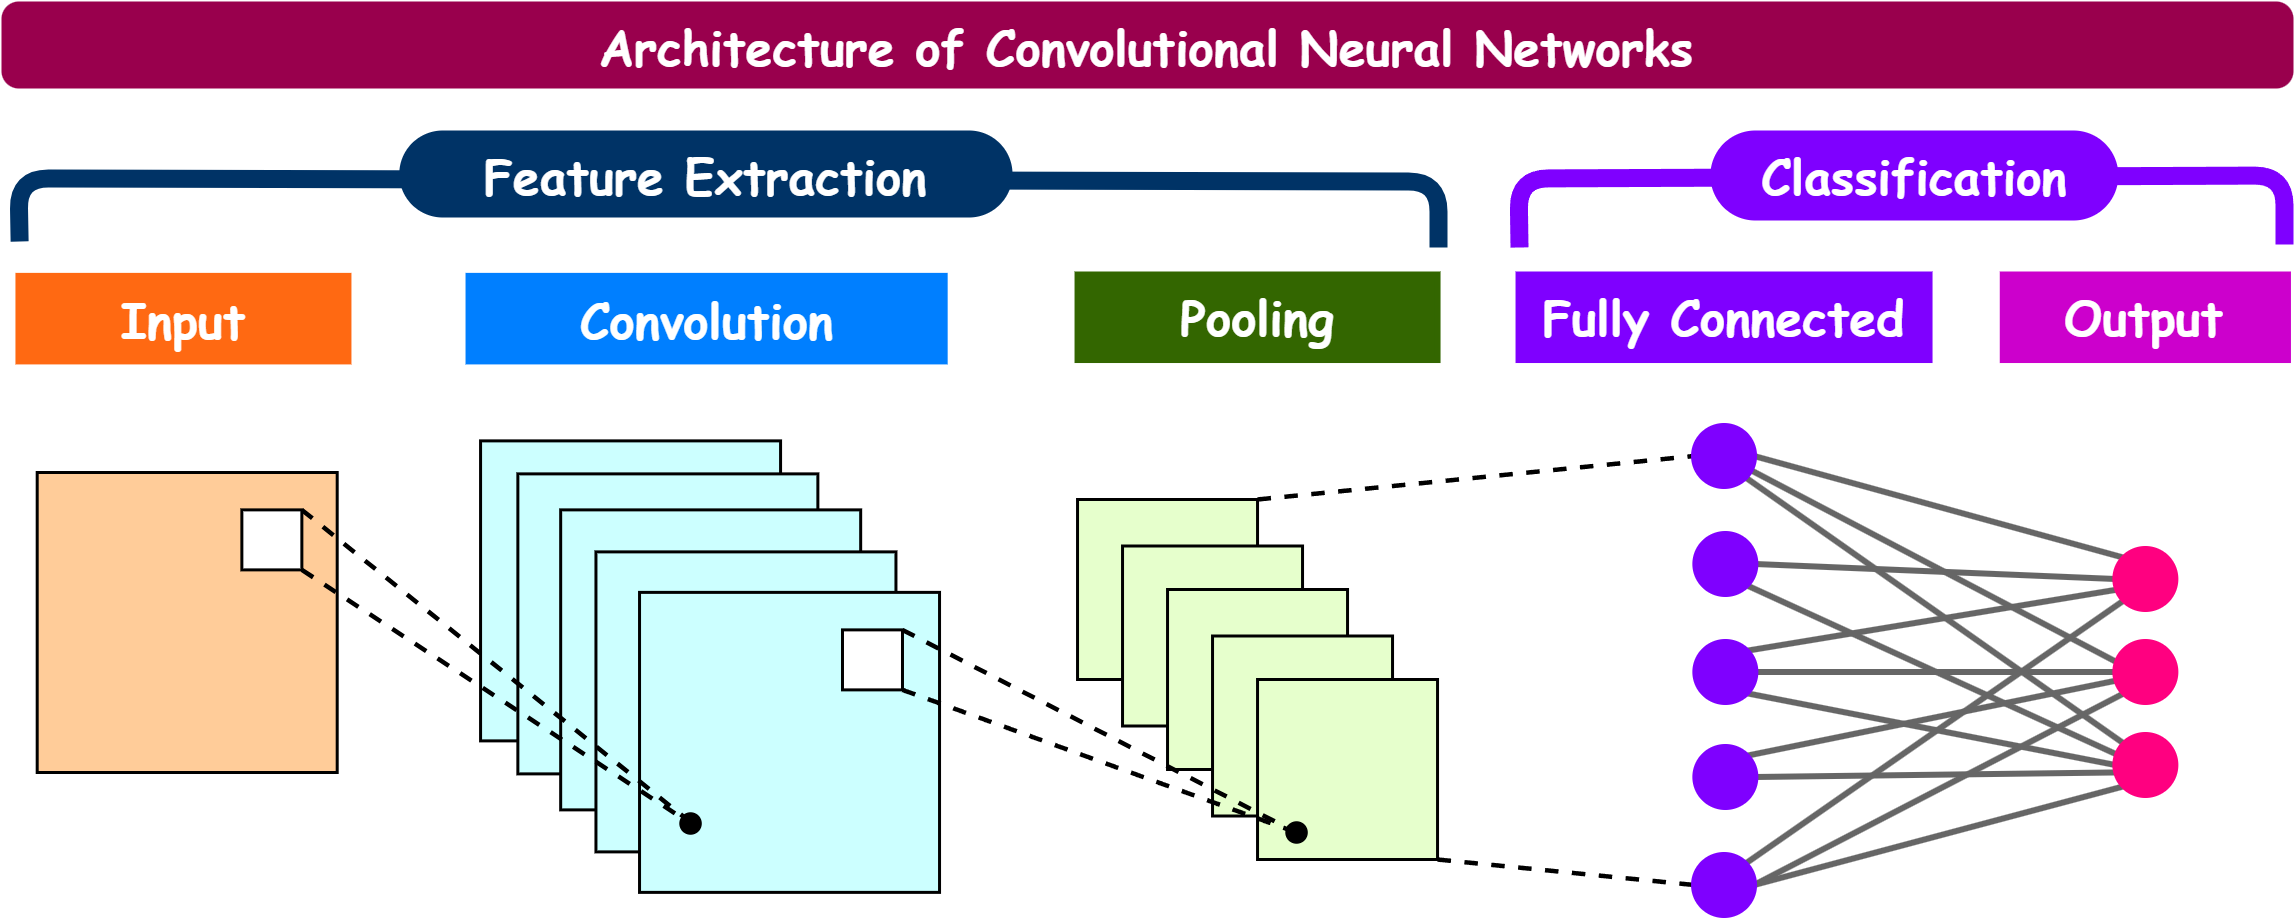

Fully connected neural networks become computationally expensive as the number of neurons and layers grows. More importantly, when applied directly to images, they treat each pixel independently — ignoring **spatial location** and **neighbourhood relationships**. CNNs solve both of these problems.

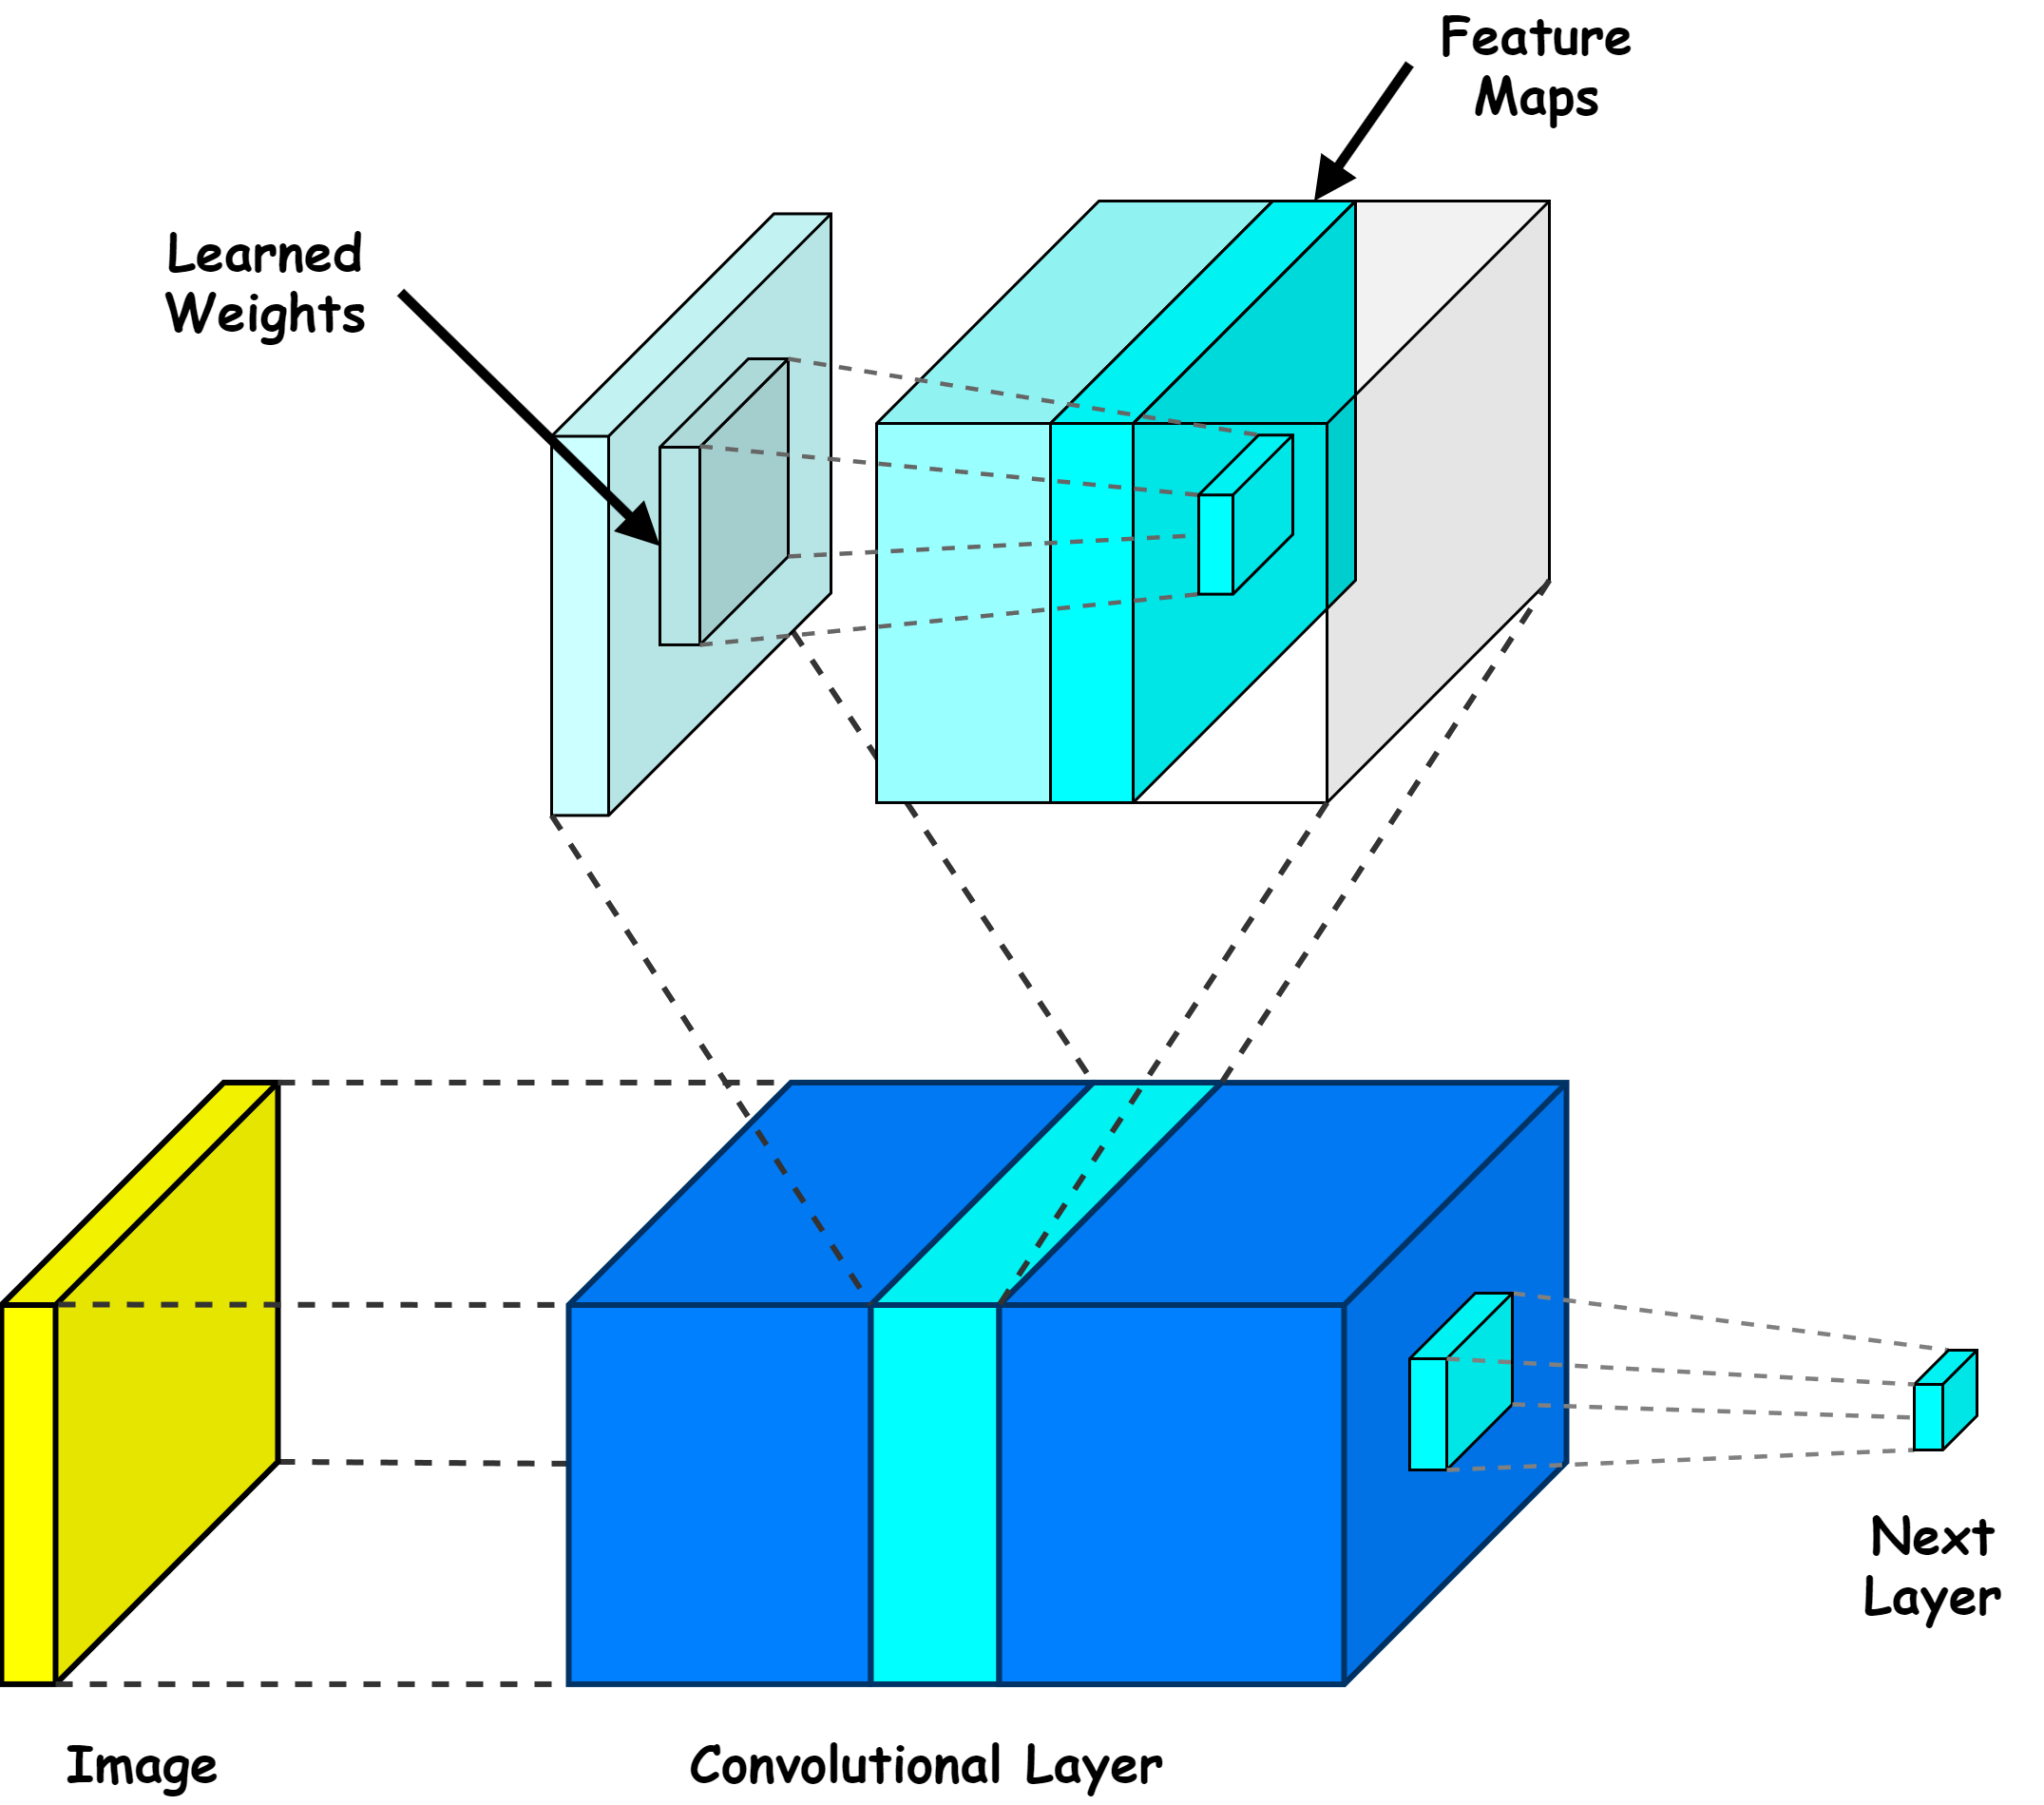

Instead of connecting every input to every neuron, a CNN applies **learnable filters** (small matrices) to the input image via convolution. Each filter slides across the image and produces a **feature map** that highlights particular patterns detected in the input.

The key difference from traditional filters (e.g., the Sobel filter used in Canny edge detection, which is manually defined and fixed) is that CNN filter weights are **learned from data** through backpropagation, the same training algorithm used in fully connected networks.

Within a single convolutional layer, **multiple filters** operate in parallel, each learning to detect different features. Stacking multiple convolutional layers allows the network to extract increasingly **complex and abstract features**, early layers might detect edges, while deeper layers capture shapes, textures, and eventually entire objects.

#### **Convolution Operation Example**

The convolution operation slides a filter across the input image, computing element-wise multiplications and summing the results at each position. For example, given an input image (green matrix) and a filter (yellow matrix with red values), the filter is convolved with **stride 1** and **no padding**, producing the output feature map (pink matrix).

Given an image patch and a filter:

$$\begin{bmatrix} 1 & 1 & 1 \\ 0 & 1 & 1 \\ 0 & 0 & 1 \end{bmatrix} * \begin{bmatrix} 1 & 0 & 1 \\ 0 & 1 & 0 \\ 1 & 0 & 1 \end{bmatrix}$$

Element-wise multiplication and sum:

$$= (1 \times 1) + (1 \times 0) + (1 \times 1) + (0 \times 0) + (1 \times 1) + (1 \times 0) + (0 \times 1) + (0 \times 0) + (1 \times 1)$$

$$= 4$$

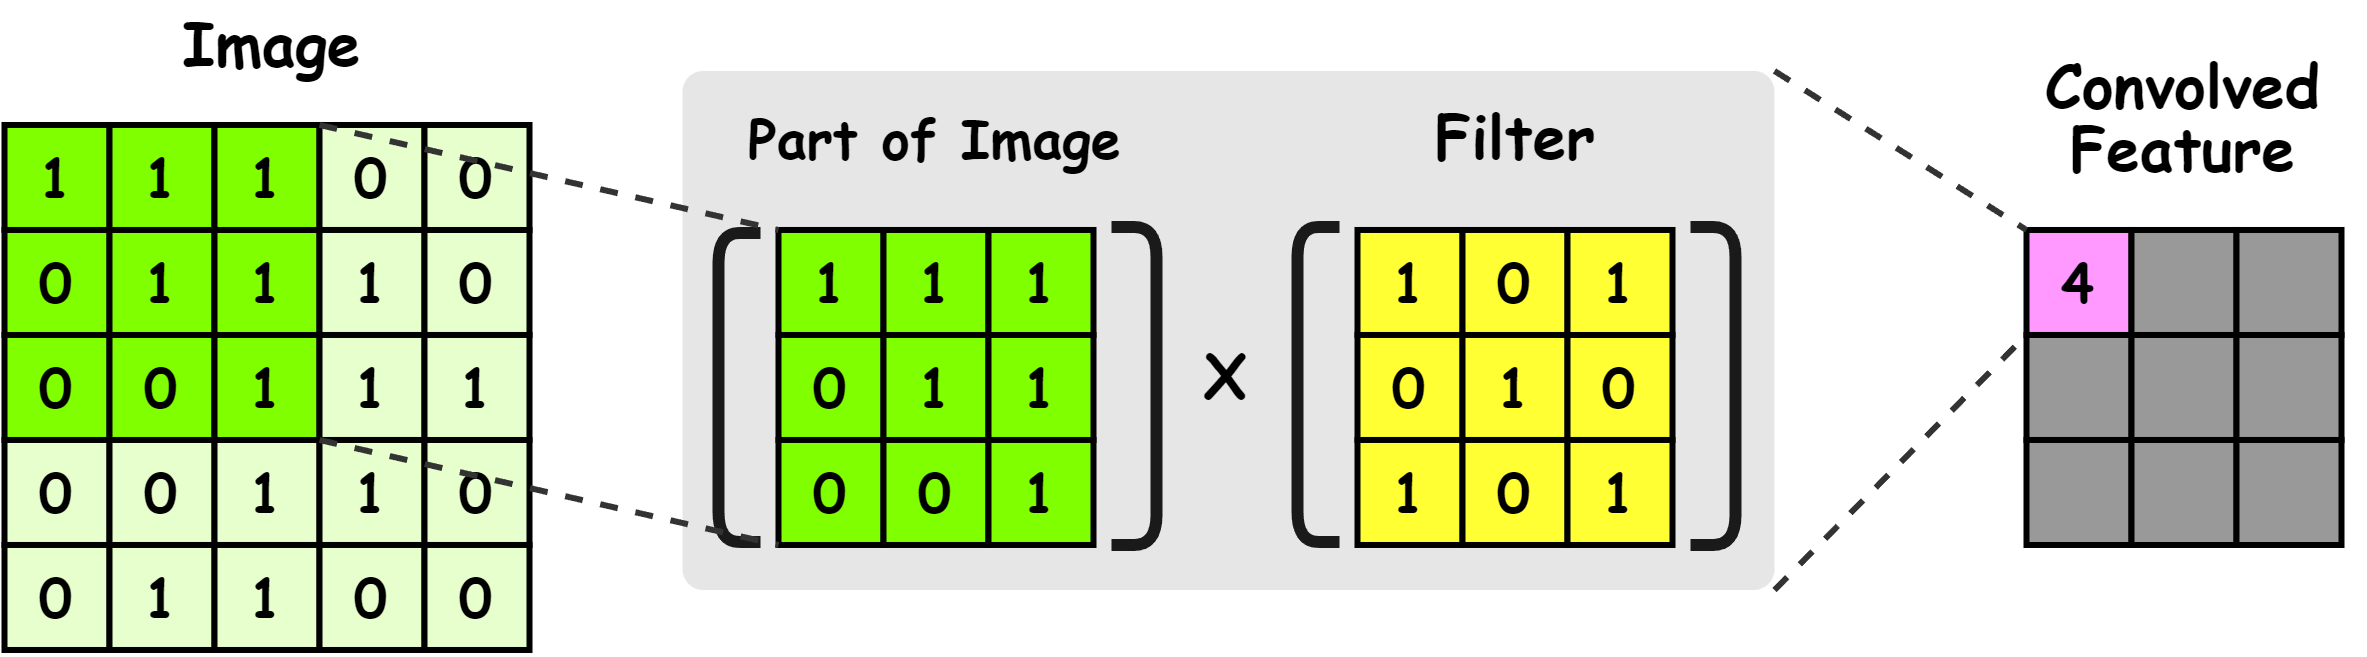

*** 

### **Pooling and Activation Functions**

#### **Activation Functions**

Convolutional layers alone only perform **linear operations**, and stacking linear operations together still produces a linear result. To allow the network to learn complex, non-linear patterns, we apply an **activation function** after each convolutional layer.

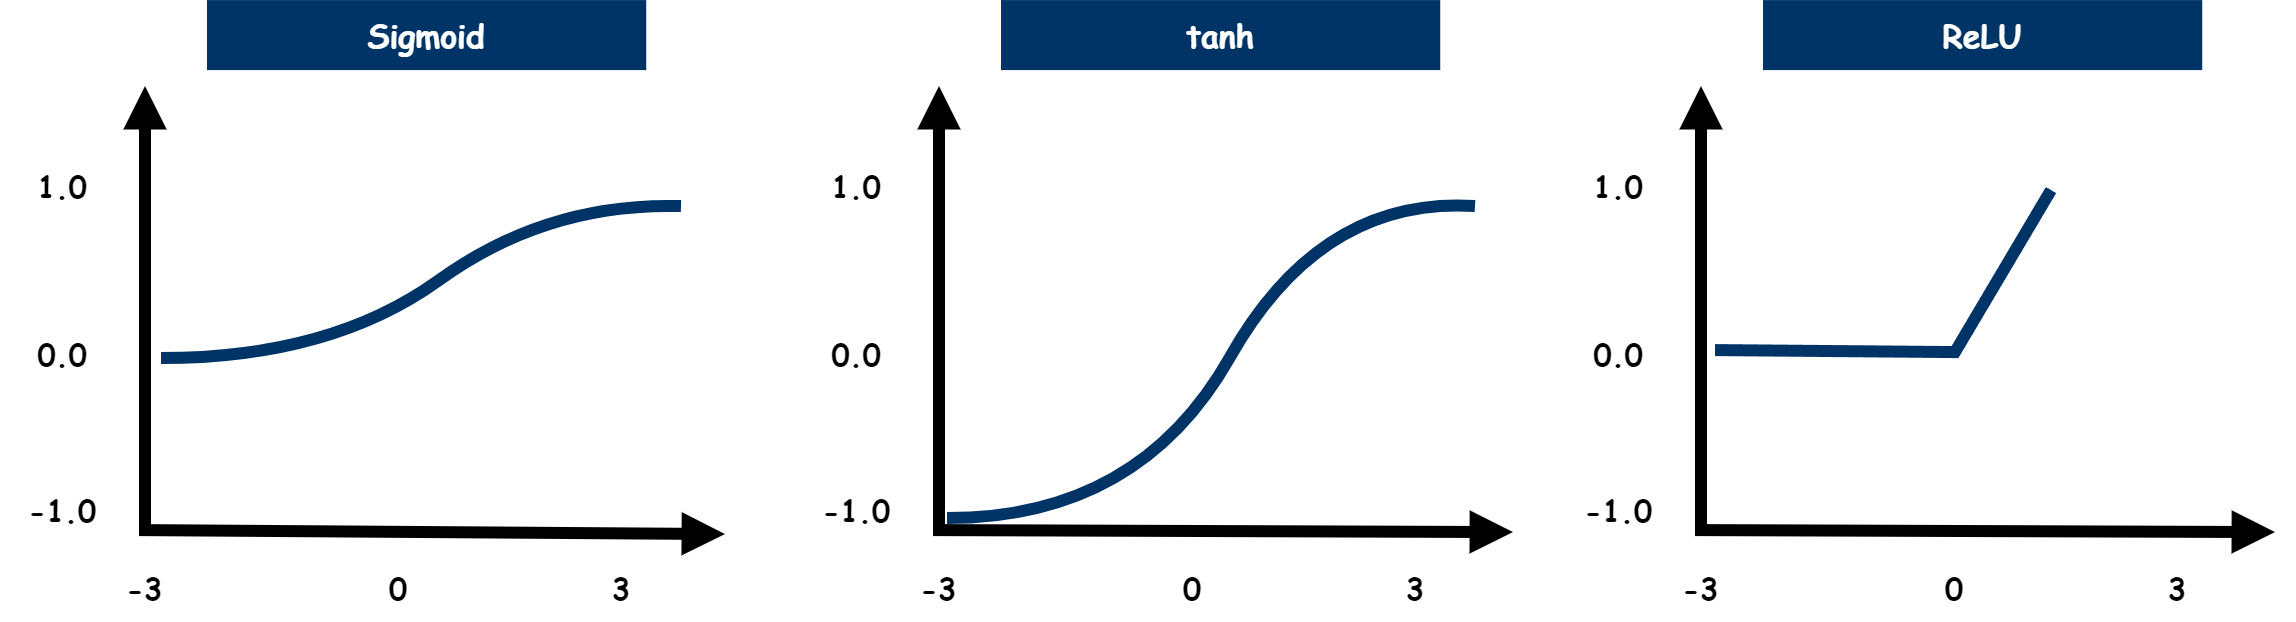

Common activation functions include:

**Logistic (Sigmoid):**

$$f(x)=\frac{1}{1+e^{-x}}$$

**Hyperbolic Tangent (tanh):**

$$f(x)=\tanh(x)$$

**Rectified Linear Unit (ReLU):**

$$f(x)=\max(0, x)$$

ReLU is the most widely used in modern CNNs due to its simplicity and effectiveness during training.

#### **Spatial Pooling**

After convolution and activation, **spatial pooling** is applied to the feature maps. Pooling reduces the spatial dimensions by summarising a local region into a single value, the most common approach is **max pooling**, which takes the maximum value within each region.

Pooling achieves two things:
- **Reduces spatial dimensions**: making the network computationally cheaper
- **Provides translation invariance**: small shifts in the input won't significantly change the output, since the max value in a region stays roughly the same

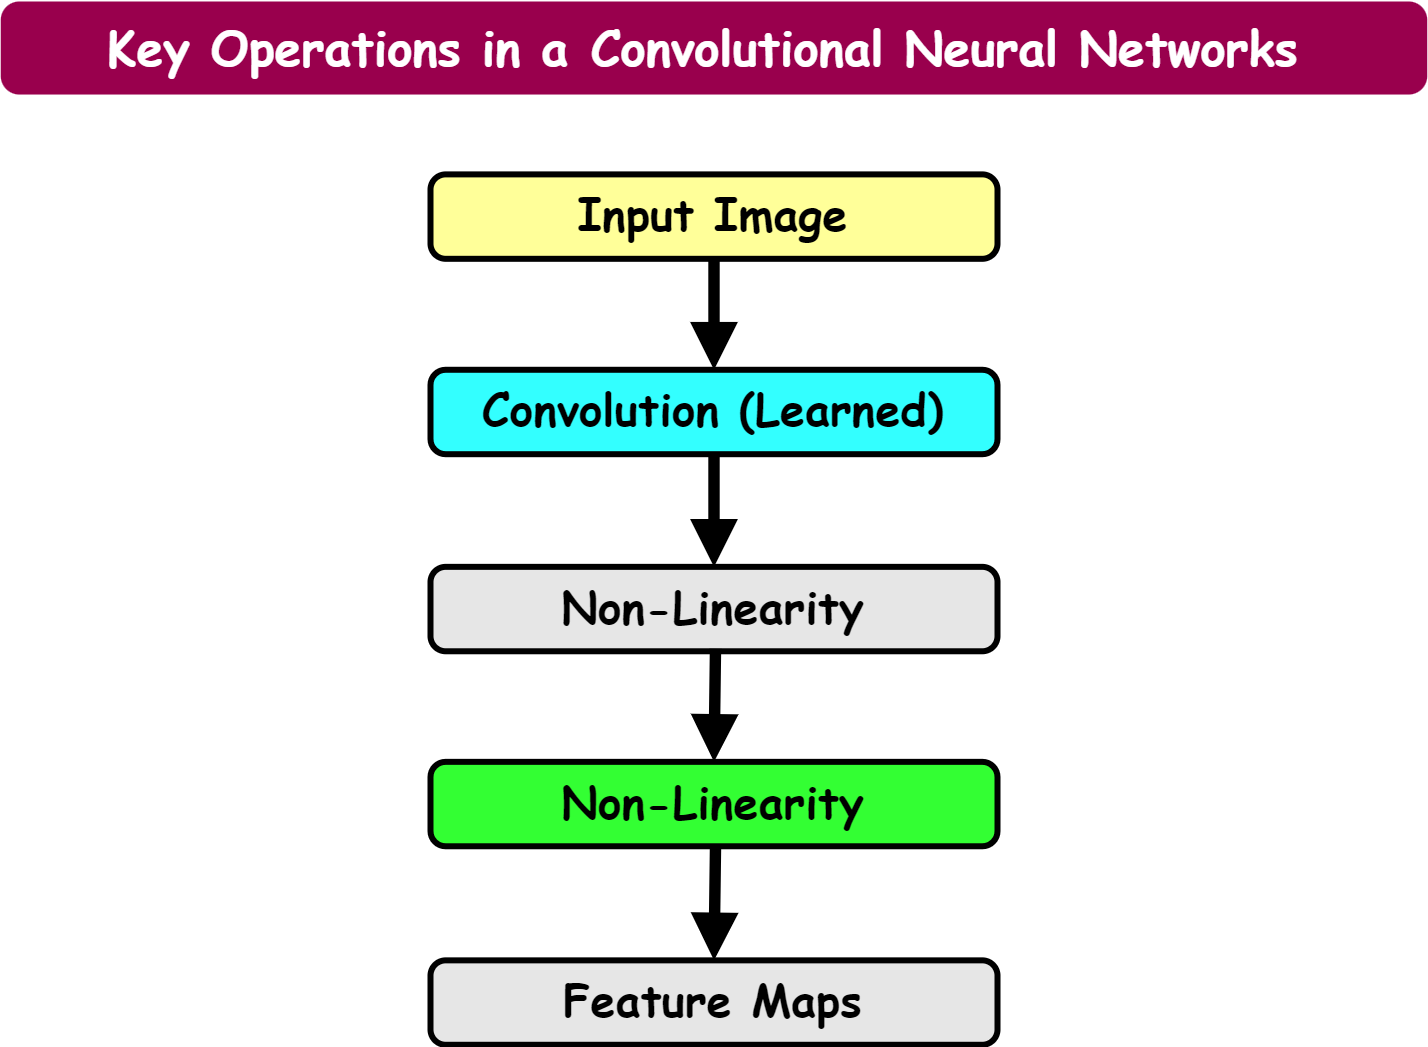